#**A/B тестирование**

Набор данных для A/B-тестирования является синтетически сгенерированным и  имитирует информацию о посещениях пользователями из Великобритании вымышленного розничного сайта. Пользователи разделены на две группы — A и B и представляют контрольную и тестовую группу соответственно.

Решаемый вопрос:
**"Люди проводят больше времени на сайте, если фон сайта белый или чёрный?"**

- **Группа A (контроль)** — фон сайта белый (текущая версия)
- **Группа B (тест)** — фон сайта чёрный (новая версия)
- **Цель:** понять, есть ли значительное улучшение в просмотрах сайта при применении новой версии.

**Описание колонок:**
- **User ID** — идентификатор пользователя
- **Group** — группа (A или B)
- **Page Views** — количество просмотренных страниц за сессию
- **Time Spent** — общее время (в секундах) на сайте
- **Conversion** — совершил ли пользователь целевое действие (Yes/No)
- **Device** — тип устройства (мобильный/десктоп)
- **Location** — регион Великобритании

Ссылка на датасет: https://www.kaggle.com/datasets/adarsh0806/ab-testing-practice

### **Загрузка датасета с kaggle**

In [24]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [25]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

path = kagglehub.dataset_download("adarsh0806/ab-testing-practice")
file_path = path + "/ab_testing.csv"
df =  pd.read_csv(file_path)

Using Colab cache for faster access to the 'ab-testing-practice' dataset.


In [26]:
df.head(10)

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland
5,13134,B,2,93,No,Desktop,Scotland
6,16702,A,5,106,No,Mobile,Northern Ireland
7,10041,B,9,292,No,Mobile,Northern Ireland
8,13191,B,8,434,No,Desktop,Northern Ireland
9,14427,B,12,271,No,Desktop,England


### **Первичный анализ данных**

In [27]:
#смотрим на размер данных
print(f"Всего записей: {len(df)}")

print("\nНаличие пропусков")
print(df.isnull().sum())

print("\nРаспределение по группам")
print(df['Group'].value_counts())

print("\nТипы данных:")
print(df.dtypes)

Всего записей: 5000

Наличие пропусков
User ID       0
Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64

Распределение по группам
Group
A    2519
B    2481
Name: count, dtype: int64

Типы данных:
User ID        int64
Group         object
Page Views     int64
Time Spent     int64
Conversion    object
Device        object
Location      object
dtype: object


In [28]:
#преобразуем Conversion в числовой формат
df['Conversion_num'] = df['Conversion'].map({'Yes': 1, 'No': 0})

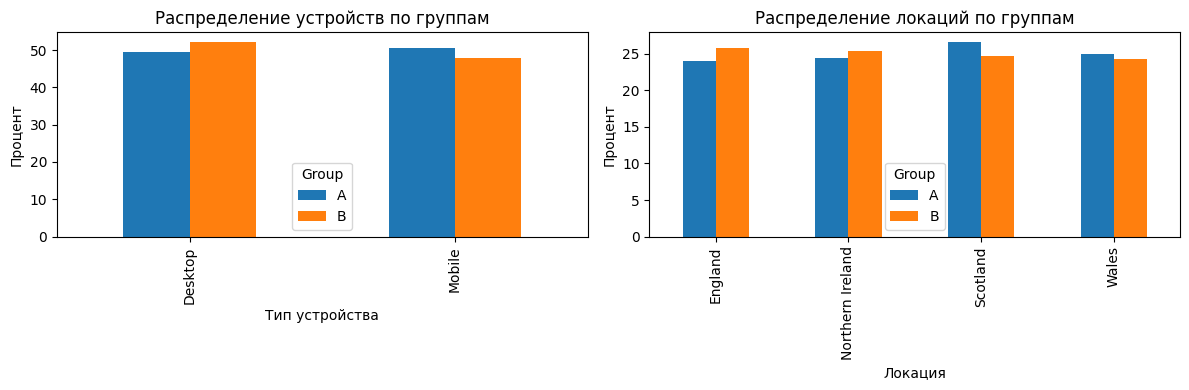

In [29]:
#распределение устройств по группам
device_check = pd.crosstab(df['Device'], df['Group'], normalize='columns') * 100

#распределение локаций по группам
location_check = pd.crosstab(df['Location'], df['Group'], normalize='columns') * 100

#визуализируем
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
device_check.plot(kind='bar', ax=axes[0])
axes[0].set_title('Распределение устройств по группам')
axes[0].set_ylabel('Процент')
axes[0].set_xlabel('Тип устройства')

location_check.plot(kind='bar', ax=axes[1])
axes[1].set_title('Распределение локаций по группам')
axes[1].set_ylabel('Процент')
axes[1].set_xlabel('Локация')
plt.tight_layout()
plt.show()

**Вывод:** данные включают 5000 записей, равномерно распределённых между группами A (2519) и B (2481). Пропуски отсутствуют.
Доли устройств и локаций в группах A и B практически идентичны, что подтверждает отсутствие систематических смещений.

Группы сопоставимы по всем наблюдаемым признакам.

### **Анализ основных показателей**

In [30]:
# Группируем данные
metrics = df.groupby('Group').agg({
    'User ID': 'count',
    'Page Views': ['mean', 'std'],
    'Time Spent': ['mean', 'std'],
    'Conversion_num': ['mean', 'std']
}).round(2)

# Переименовываем колонки
metrics.columns = ['users', 'page_views_mean', 'page_views_std', 'time_spent_mean', 'time_spent_std', 'conversion_mean', 'conversion_std']
metrics = metrics.reset_index()

print(metrics)

  Group  users  page_views_mean  page_views_std  time_spent_mean  \
0     A   2519             7.58            4.08           241.73   
1     B   2481             7.49            3.96           243.30   

   time_spent_std  conversion_mean  conversion_std  
0          117.34             0.05            0.23  
1          119.19             0.14            0.35  


In [31]:
# Рассчитываем относительное улучшение
group_a = metrics[metrics['Group'] == 'A'].iloc[0]
group_b = metrics[metrics['Group'] == 'B'].iloc[0]

lift_time = (group_b['time_spent_mean'] - group_a['time_spent_mean']) / group_a['time_spent_mean'] * 100
lift_pages = (group_b['page_views_mean'] - group_a['page_views_mean']) / group_a['page_views_mean'] * 100
lift_conv = (group_b['conversion_mean'] - group_a['conversion_mean']) / group_a['conversion_mean'] * 100

print("\n LIFT: ")
print(f"Время на сайте: {lift_time:.1f}%")
print(f"Просмотры страниц: {lift_pages:.1f}%")
print(f"Конверсия: {lift_conv:.1f}%")


 LIFT: 
Время на сайте: 0.6%
Просмотры страниц: -1.2%
Конверсия: 180.0%


**Вывод:** чёрный фон (группа B) показал сильный рост конверсии — с 5% до 14% (+180%). Однако время на сайте увеличилось незначительно (+0.6%), а просмотры страниц даже немного снизились (-1.2%). Это говорит о том, что новый дизайн влияет не на вовлечённость пользователя в контент и продукцию на сайте, а на способность убедить пользователя совершить целевое действие сразу. Чёрный фон ускоряет принятие решения о покупке: пользователи проводят столько же времени на сайте, но с большей вероятностью завершают сессию покупкой.

### **Статистическая значимость основных показателей**

In [32]:
# Разделяем данные
group_a_time = df[df['Group'] == 'A']['Time Spent']
group_b_time = df[df['Group'] == 'B']['Time Spent']

group_a_conv = df[df['Group'] == 'A']['Conversion_num']
group_b_conv = df[df['Group'] == 'B']['Conversion_num']

#T-тест для времени на сайте
t_stat, p_value_time = stats.ttest_ind(group_b_time, group_a_time)

print("Время на сайте:")
print(f" T-статистика: {t_stat:.4f}")
print(f" P-value: {p_value_time:.4f}")
if p_value_time < 0.05:
    print("Статистически значимо! (p < 0.05)")
else:
    print("Статистически не значимо (p >= 0.05)")

Время на сайте:
 T-статистика: 0.4695
 P-value: 0.6387
Статистически не значимо (p >= 0.05)


In [33]:
# T-тест для просмотров страниц
t_stat_pages, p_value_pages = stats.ttest_ind(
    df[df['Group'] == 'B']['Page Views'],
    df[df['Group'] == 'A']['Page Views']
)

print("Просмотры страниц:")
print(f" T-статистика: {t_stat_pages:.4f}")
print(f" P-value: {p_value_pages:.4f}")
if p_value_time < 0.05:
    print("Статистически значимо! (p < 0.05)")
else:
    print("Статистически не значимо (p >= 0.05)")

Просмотры страниц:
 T-статистика: -0.7790
 P-value: 0.4360
Статистически не значимо (p >= 0.05)


In [36]:
# Z-тест для конверсии
n_a = len(group_a_conv)
n_b = len(group_b_conv)
conv_a = group_a_conv.mean()
conv_b = group_b_conv.mean()
conv_pooled = (group_a_conv.sum() + group_b_conv.sum()) / (n_a + n_b)

z_score = (conv_b - conv_a) / np.sqrt(conv_pooled * (1 - conv_pooled) * (1/n_a + 1/n_b))
p_value_conv = 2 * (1 - stats.norm.cdf(abs(z_score)))

print("Конверсия:")
print(f" Z-статистика: {z_score:.4f}")
print(f" P-value: {p_value_conv:.4f}")
if p_value_conv < 0.05:
    print("Статистически значимо! (p < 0.05)")
else:
    print("Статистически не значимо (p >= 0.05)")

Конверсия:
 Z-статистика: 10.3545
 P-value: 0.0000
Статистически значимо! (p < 0.05)


**Вывод:** можно сказать, что разница во времени и в просмотрах между группами случайна, а разница в конверсии не случайна. Конверсия — единственная метрика, на которую действительно повлиял чёрный фон.

Чёрный фон работает как "триггер принятия решения". Пользователи проводят на сайте столько же времени и смотрят столько же страниц, но с большей вероятностью завершают сессию покупкой. Вероятно, он создает ощущение серьёзности и качества бренда и продукции.

**Рекомендация:** внедрять чёрный фон для всех пользователей — эффект на конверсию доказан статистически.




### **Визуализация результатов**

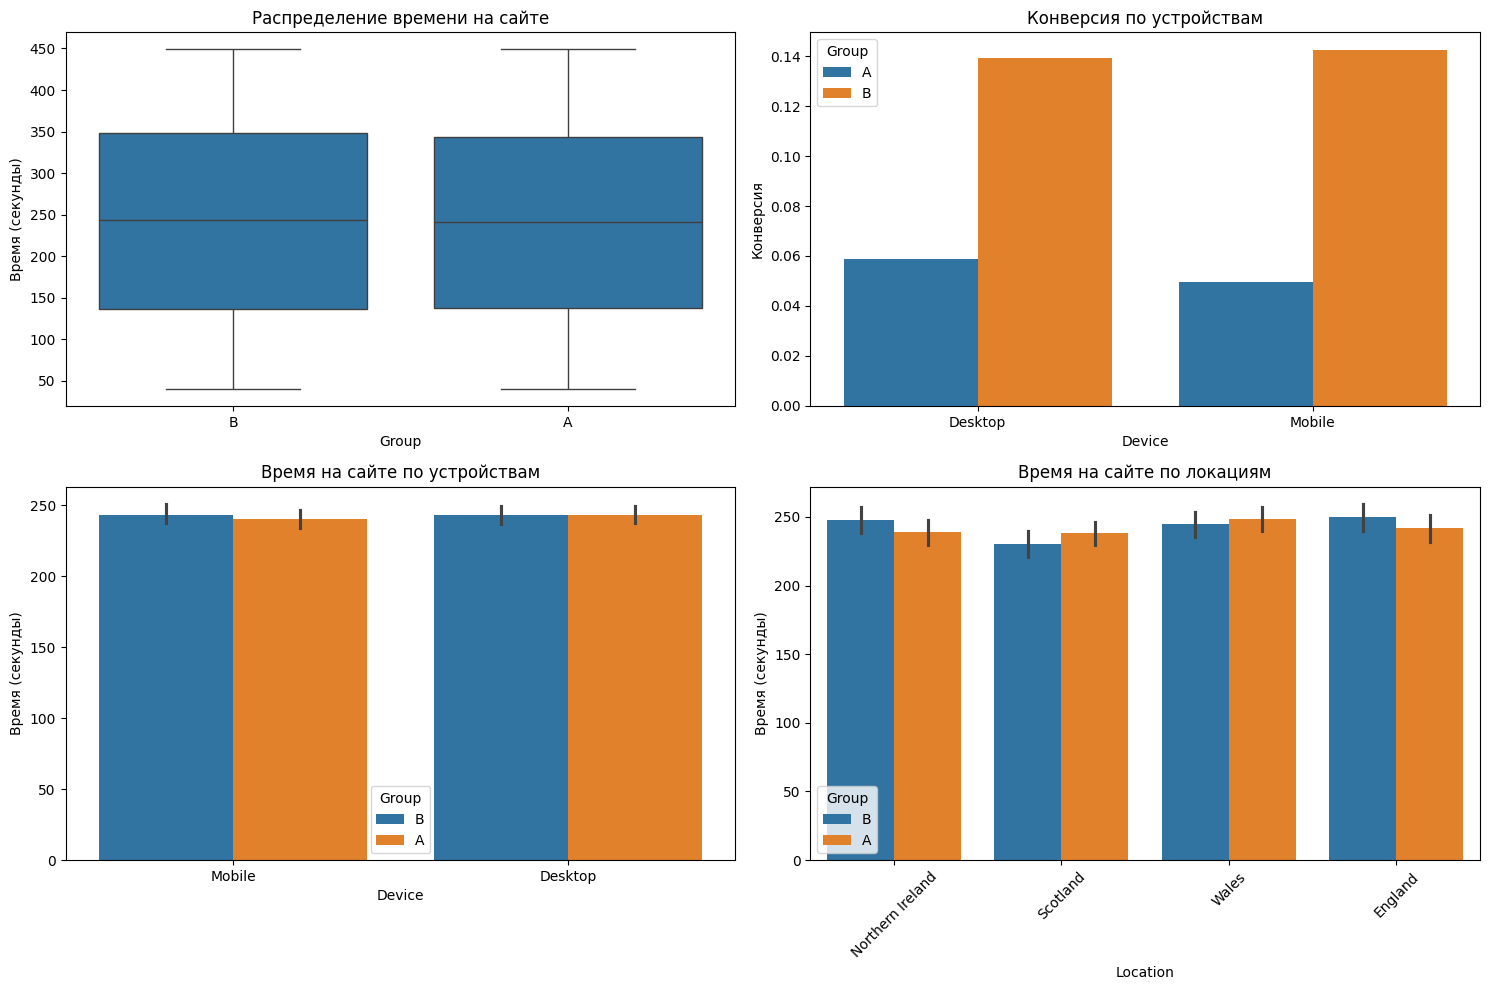

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Распределение времени на сайте
sns.boxplot(data=df, x='Group', y='Time Spent', ax=axes[0,0])
axes[0,0].set_title('Распределение времени на сайте')
axes[0,0].set_ylabel('Время (секунды)')

# Время по устройствам
sns.barplot(data=df, x='Device', y='Time Spent', hue='Group', ax=axes[1,0])
axes[1,0].set_title('Время на сайте по устройствам')
axes[1,0].set_ylabel('Время (секунды)')

# Конверсия по устройствам
device_conv = df.groupby(['Device', 'Group'])['Conversion_num'].mean().reset_index()
sns.barplot(data=device_conv, x='Device', y='Conversion_num', hue='Group', ax=axes[0,1])
axes[0,1].set_title('Конверсия по устройствам')
axes[0,1].set_ylabel('Конверсия')

# Время по локациям
sns.barplot(data=df, x='Location', y='Time Spent', hue='Group', ax=axes[1,1])
axes[1,1].set_title('Время на сайте по локациям')
axes[1,1].set_ylabel('Время (секунды)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()